In [2]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

# cada linha representa uma transação financeira
# coluna time representa o momento da transação
# as colunas v1 ate v28 são variaveis processadas, usando tecnicas chamadas de PCA, para preservar a privacidade
# amount representa o valor da transação
# class indica se a transação é fraudulenta (1) ou não (0)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# calculando a proporção de transações fraudulentas e não fraudulentas
df["Class"].value_counts(normalize=True)

# esses valores são ruins para treinar um modelo de machine learning, pois o modelo pode aprender a sempre prever a classe majoritária (não fraudulenta) e ainda assim ter uma acurácia alta. Por isso, é importante balancear os dados antes de treinar o modelo.

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [4]:
# Feature Engineering 

import numpy as np

# criando uma nova variavel, e o np.log() aplica uma transformação logarítmica nos valores da coluna Amount
df["Amount_log"] = np.log1p(df["Amount"])

In [5]:
from sklearn.preprocessing import StandardScaler

# scaler faz os uma transformação nos dados para que tenha uma media igual a zero e um desvio padrão igual a 1, o que ajuda a melhorar a performance do modelo de machine learning
scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [6]:
from sklearn.model_selection import train_test_split

x = df.drop("Class", axis=1)
y = df["Class"]

# stratify=y garante que a proporção dos valores de fraudes e nao fraudes seja mantida 
x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
)

In [7]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

# Logistic Regression é um modelo de machine learning usado para classificação binária, ou seja, quando queremos prever uma variável que pode assumir apenas dois valores (0 ou 1, verdadeiro ou falso, sim ou não). Ele é chamado de "regressão" porque estima a probabilidade de um evento ocorrer com base em variáveis independentes.
model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

c:\Users\gabri\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
# Métricas de avaliação do modelo

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

# 0 representa as transações normais
# 1 representa as transações fraudulentas

# precision 0.83 significa que o modelo acertou 83% das transações fraudulentas, mas errou 17%
# recall (foco) 0.68 significa que o modelo acertou 68% das transsações fraudulentas, mas errou 32% siginifica que o modelo esta deixando passar 32% de transações fraudulentas.
# f1-score 0.77 e o equilibrio entre precisão e recall, ou seja, o modelo tem uma boa performance tanto em acertar as transações fraudulentas quanto em não deixar passar muitas transações fraudulentas. (visão geral da qualidade do modelo)

# accuracy 1.00 como o dataset e desbalanciado, ele etende que a acuracia e quase 100% pq ele acertou a maioria das transações normais, mas errou muitas transações fraudulentas.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.83      0.68      0.74       148

    accuracy                           1.00     85443
   macro avg       0.91      0.84      0.87     85443
weighted avg       1.00      1.00      1.00     85443



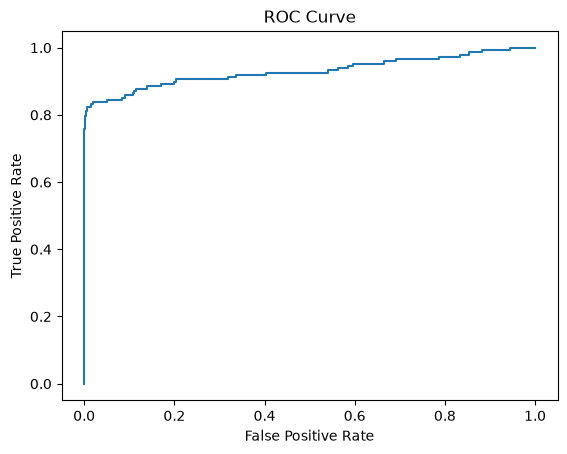

AUC Score: 0.9300096802353676


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_probs))

# true positive = quantidade de transações fraudulentas que o modelo acertou
# false positive = quantidade de transações normais que o modelo errou, ou seja, classificou como fraudulentas

# true negative = quantidade de transações normais que o modelo acertou
# false negative = quantidade de transações fraudulentas que o modelo errou, ou seja, classificou como normais

# AUC (Area Under the Curve) é uma métrica que mede a capacidade do modelo de distinguir entre classes. Quanto maior o AUC, melhor o modelo é em classificar corretamente as transações fraudulentas e não fraudulentas. Um AUC de 0,5 indica que o modelo não tem capacidade de discriminação, enquanto um AUC de 1,0 indica que o modelo é perfeito na classificação.

# com 93% e um AUC de 0,93, o modelo tem uma boa capacidade de discriminação entre transações fraudulentas e não fraudulentas, mas ainda pode ser melhorado.

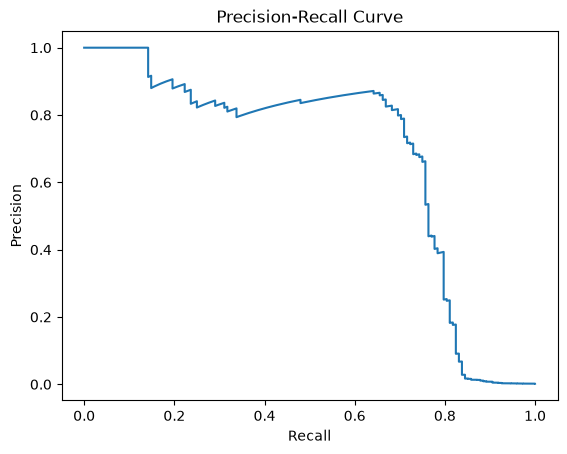

In [12]:
# (outra metrica)

from  sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [ ]:
# Balanceamento dos dados 

# Undersampling: consiste em reduzir a quantidade de amostras da classe majoritária (não fraudulenta) para que fique mais equilibrada com a classe minoritária (fraudulenta). Isso pode ser feito removendo aleatoriamente algumas amostras da classe majoritária.

fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(n=len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [ ]:
# Oversampling: consiste em aumentar a quantidade de amostras da classe minoritária (fraudulenta) para que fique mais equilibrada com a classe majoritária (não fraudulenta). Isso pode ser feito duplicando aleatoriamente algumas amostras da classe minoritária ou gerando novas amostras sintéticas usando técnicas como SMOTE (Synthetic Minority Over-sampling Technique).

from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_res, y_res = smote.fir_resample(x, y)


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    # escolhendo 50 arvores para o modelo
    n_estimators=50, 
    # limitando a profundidade das arvores para evitar overfitting
    max_depth=10,
    # esta balanceando as classes para que o modelo nao fique enviesado para a classe majoritaria
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
    )

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

# recall esta 0.80 aumentou, ou seja esta identificando mais fraudes
# f1-score esta 0.77 isso e bom, pois o modelo esta equilibrado entre precisão e recall, ou seja, o modelo tem uma boa performance tanto em acertar as transações fraudulentas quanto em não deixar passar muitas transações fraudulentas. (visão geral da qualidade do modelo)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.74      0.80      0.77       148

    accuracy                           1.00     85443
   macro avg       0.87      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



In [14]:
# Pipeline serve para organizar o fluxo de trabalho de machine learning, permitindo que você encadeie várias etapas de pré-processamento e modelagem em um único objeto. Isso facilita a manutenção do código, a reprodução de resultados e a aplicação consistente das mesmas transformações em novos dados.

from sklearn.pipeline import Pipeline

# os dados passam primeiro pela padronização e dps pelo modelo de regressão logística, tudo em um unico fluxo

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

x_pred = pipeline.predict(x_test)

In [15]:
# threshold geralemnte e 0.5, ou seja se a probabilidade de ser fraude for maior que 0.5, o modelo classifica como FRAUDE, caso contrario classifica como normal.

# aqui esta 0.3 para ser mais sensivel a identificar fraudes, ou seja, o modelo vai classificar como fraude mesmo que a probabilidade seja menor que 0.5, mas maior que 0.3.
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print (classification_report(y_test, y_pred_custom))

# precision esta 0.78 o que e bom ainda esta confiavel
# recall esta 0.71 o que esta bom tambem a ideia era aumentar o recall

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.78      0.71      0.74       148

    accuracy                           1.00     85443
   macro avg       0.89      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
# Modelo Avançado - XGBoost

# XGBoost gera as avores sequencial e cada arvore tenta corrigir os erros da arvore anterior, ou seja, ele aprende com os erros do modelo anterior e tenta melhorar a performance do modelo como um todo.
# RandomForest gera as arvores e ela so se conectam no final, ou seja, cada arvore e independente e nao aprende com os erros das outras arvores.

from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10, # ajuda com o balanceamento 
    use_label_encoder=False,
    eval_metric="logloss"
    )

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

c:\Users\gabri\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print(classification_report(y_test, y_pred_xgb))

# 0.94 de precision, ou seja, o modelo acertou 94% das transações fraudulentas, mas errou 6%
# recall 0.78, ou seja, o modelo acertou 78% das transações fraudulentas, mas errou 22%
# f1-score 0.85, ou seja, o modelo tem uma boa performance tanto em acertar as transações fraudulentas quanto em não deixar passar muitas transações fraudulentas. (visão geral da qualidade do modelo)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



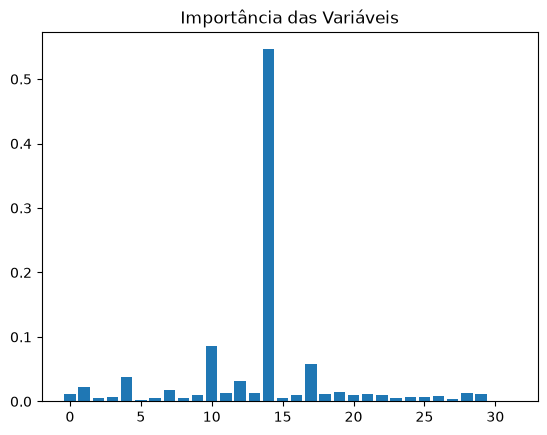

In [ ]:
# importancia das variaveis

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das Variáveis")
plt.show()

# horizontal de 0 a 30 mostra que as variaveis mais importantes para o modelo sao v14, v17, v12, v10 e v11, ou seja, essas variaveis tem mais influencia na hora de classificar uma transação como fraudulenta ou nao.
# vertical de 0 a 0.5 mostra que a importancia das variaveis mais importantes sao em torno de 0.5, ou seja, essas variaveis tem uma influencia significativa na hora de classificar uma transação como fraudulenta

In [ ]:
# Ajuste de hiperparametros

from sklearn.model_selection import GridSearchCV

param_grid = {
    "max-depth": [3, 5],
    "n_estimators": [50, 100]
}

# uma tecnica para testar varias combinações de parametros e encontrar a melhor combinação para o modelo. Ele faz isso dividindo os dados em k partes (k-fold cross-validation) e treinando o modelo com diferentes combinações de parâmetros em cada parte, avaliando o desempenho do modelo com uma métrica de avaliação (nesse caso, recall). No final, ele retorna a melhor combinação de parâmetros que obteve o melhor desempenho.
# um conjunto de combinações de parâmetros para tester o modelo, nesse caso, estamos testando duas profundidades diferentes (3 e 5) e dois números de árvores diferentes (50 e 100). O GridSearchCV vai testar todas as combinações possíveis desses parâmetros e retornar a melhor combinação que obteve o melhor desempenho do modelo.
grid = GridSearchCV(
    XGBClassifier(eval_metrics="logloss"),
    param_grid,
    # scoring = "recall" significa que o modelo vai ser avaliado com base na métrica de recall, ou seja, ele vai tentar maximizar a quantidade de transações fraudulentas que o modelo acerta, mesmo que isso signifique aumentar a quantidade de transações normais que o modelo erra.
    scoring="recall",
    cv=3
)

grid.fit(x_train, y_train)

print("Melhor modelo:", grid.best_params_)

c:\Users\gabri\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:26:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics", "max-depth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:26:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics", "max-depth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:26:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics", "max-depth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gabri\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:

Melhor modelo: {'max-depth': 3, 'n_estimators': 50}


c:\Users\gabri\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


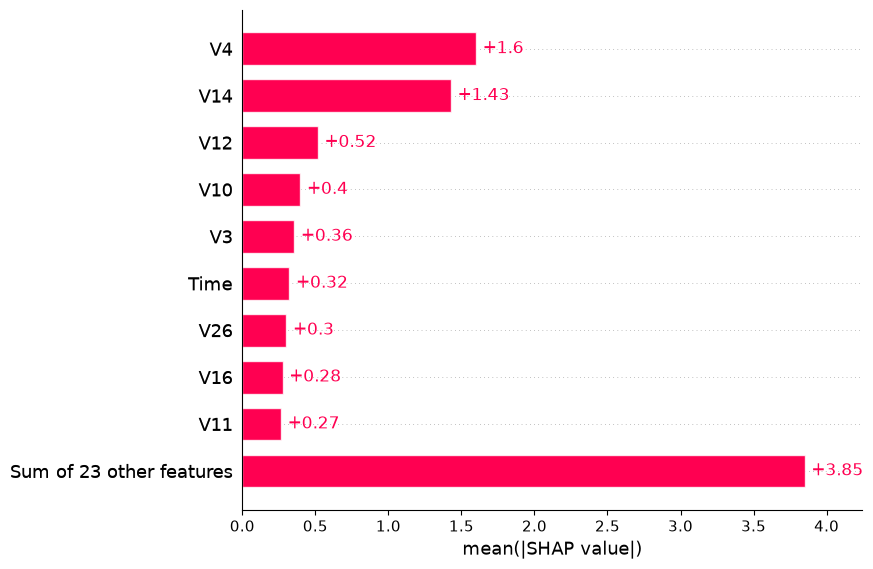

In [ ]:
# Explicabilidade (SHAP)

# uma tecnica que vai explicar como cada varivael influenciou na decisão do modelo, ou seja, ele vai mostrar quais variaveis foram mais importantes para o modelo classificar uma trans

import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)